# EDA: feature engineering parameters

Exploration only, nothing here is load-bearing (see CLAUDE.md). Goal: pick a rolling window size and Savitzky-Golay filter parameters for `src/features.py` by looking at what actually smooths sensor noise without erasing the real degradation trend, instead of guessing.

In [1]:
import os
import sys

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from src.load import load_train, SENSOR_COLS

%matplotlib inline

## Which sensor actually shows a degradation trend?

Using FD001 (single condition, no regime confound) so this is about smoothing choice, not regime mixing. Rank sensors by how strongly they correlate with cycle number within a unit, averaged across units.

In [2]:
df = load_train("FD001")

corrs = {}
for s in SENSOR_COLS:
    per_unit_corr = df.groupby("unit").apply(lambda g: g["cycle"].corr(g[s]), include_groups=False)
    corrs[s] = per_unit_corr.abs().mean()

for s, c in sorted(corrs.items(), key=lambda x: -x[1])[:8]:
    print(f"{s}: avg |corr| with cycle = {c:.3f}")

C:\Users\luise\PycharmProjects\nasa-cmapss-rul\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\luise\PycharmProjects\nasa-cmapss-rul\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


s11: avg |corr| with cycle = 0.811
s12: avg |corr| with cycle = 0.790
s4: avg |corr| with cycle = 0.782
s7: avg |corr| with cycle = 0.762
s15: avg |corr| with cycle = 0.725
s21: avg |corr| with cycle = 0.717
s20: avg |corr| with cycle = 0.714
s13: avg |corr| with cycle = 0.687


**s11 wins** (avg |corr| ~0.81). Use it to compare smoothing options on a single engine.

## Raw vs. rolling mean vs. Savitzky-Golay

Same unit, same sensor, several candidate parameters overlaid.

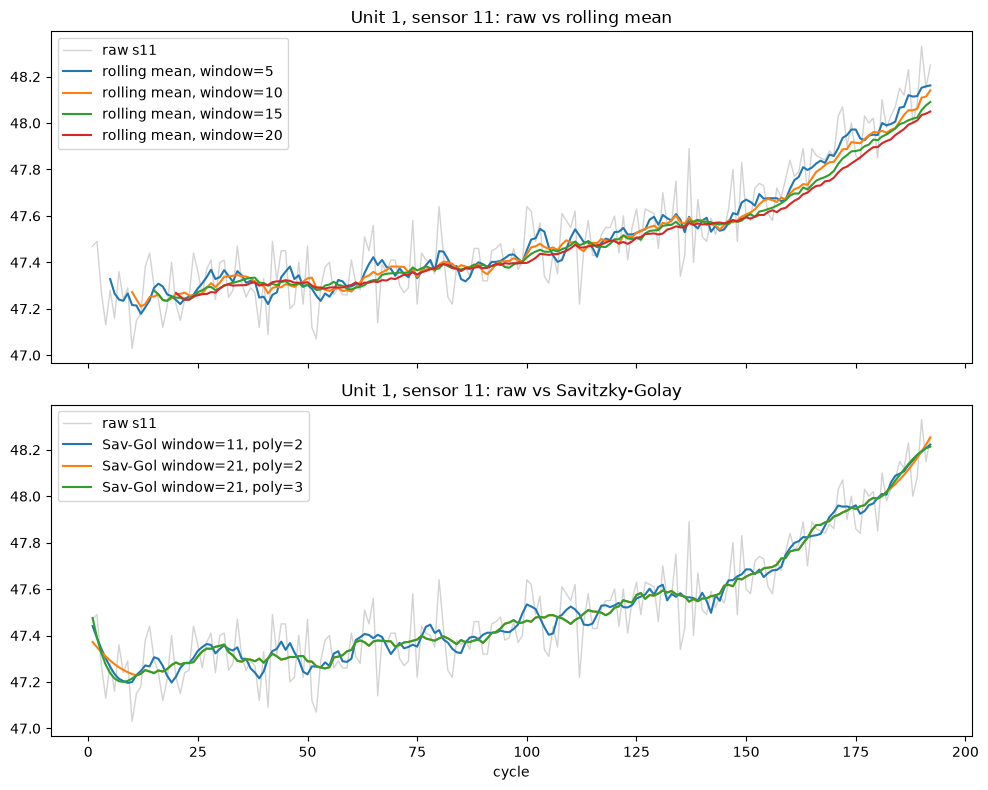

In [3]:
unit = df[df["unit"] == 1].sort_values("cycle")
x = unit["cycle"].values
y = unit["s11"].values

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax = axes[0]
ax.plot(x, y, color="lightgray", label="raw s11", linewidth=1)
ax.plot(x, unit["s11"].rolling(5).mean(), label="rolling mean, window=5")
ax.plot(x, unit["s11"].rolling(10).mean(), label="rolling mean, window=10")
ax.plot(x, unit["s11"].rolling(15).mean(), label="rolling mean, window=15")
ax.plot(x, unit["s11"].rolling(20).mean(), label="rolling mean, window=20")
ax.set_title("Unit 1, sensor 11: raw vs rolling mean")
ax.legend()

ax = axes[1]
ax.plot(x, y, color="lightgray", label="raw s11", linewidth=1)
ax.plot(x, savgol_filter(y, window_length=11, polyorder=2), label="Sav-Gol window=11, poly=2")
ax.plot(x, savgol_filter(y, window_length=21, polyorder=2), label="Sav-Gol window=21, poly=2")
ax.plot(x, savgol_filter(y, window_length=21, polyorder=3), label="Sav-Gol window=21, poly=3")
ax.set_title("Unit 1, sensor 11: raw vs Savitzky-Golay")
ax.set_xlabel("cycle")
ax.legend()

plt.tight_layout()
plt.show()